# **D502 Data Analytics Capstone**

## Ditte Joergensen

Research Question: Is there a relationship between flight distance and arrival delay in U.S. domestic flights?

### Data Wrangling

This section will be loading in the dataset and exploring the structure of it. This will include looking for null or missing values, duplicates and wrong datatypes. The cleaning of the dataset will also be included in this section.

In [1]:
# import necessary packages and libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
# download flight dataset into notebook
flights_raw = pd.read_csv("flights_sample_3m.csv")

# make copy of dataset for cleaning
flights = flights_raw.copy()

In [3]:
flights.head()

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
0,2019-01-09,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,1562,FLL,"Fort Lauderdale, FL",EWR,"Newark, NJ",...,0.0,186.0,176.0,153.0,1065.0,NaN,NaN,NaN,NaN,NaN
1,2022-11-19,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,1149,MSP,"Minneapolis, MN",SEA,"Seattle, WA",...,0.0,235.0,236.0,189.0,1399.0,NaN,NaN,NaN,NaN,NaN
2,2022-07-22,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,459,DEN,"Denver, CO",MSP,"Minneapolis, MN",...,0.0,118.0,112.0,87.0,680.0,NaN,NaN,NaN,NaN,NaN
3,2023-03-06,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,2295,MSP,"Minneapolis, MN",SFO,"San Francisco, CA",...,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0
4,2020-02-23,Spirit Air Lines,Spirit Air Lines: NK,NK,20416,407,MCO,"Orlando, FL",DFW,"Dallas/Fort Worth, TX",...,0.0,181.0,182.0,153.0,985.0,NaN,NaN,NaN,NaN,NaN


In [4]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000000 entries, 0 to 2999999
Data columns (total 32 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   FL_DATE                  str    
 1   AIRLINE                  str    
 2   AIRLINE_DOT              str    
 3   AIRLINE_CODE             str    
 4   DOT_CODE                 int64  
 5   FL_NUMBER                int64  
 6   ORIGIN                   str    
 7   ORIGIN_CITY              str    
 8   DEST                     str    
 9   DEST_CITY                str    
 10  CRS_DEP_TIME             int64  
 11  DEP_TIME                 float64
 12  DEP_DELAY                float64
 13  TAXI_OUT                 float64
 14  WHEELS_OFF               float64
 15  WHEELS_ON                float64
 16  TAXI_IN                  float64
 17  CRS_ARR_TIME             int64  
 18  ARR_TIME                 float64
 19  ARR_DELAY                float64
 20  CANCELLED                float64
 21  CANCELLATION_CODE  

In [5]:
flights.shape

(3000000, 32)

In [6]:
flights.isna().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                     77615
DEP_DELAY                    77644
TAXI_OUT                     78806
WHEELS_OFF                   78806
WHEELS_ON                    79944
TAXI_IN                      79944
CRS_ARR_TIME                     0
ARR_TIME                     79942
ARR_DELAY                    86198
CANCELLED                        0
CANCELLATION_CODE          2920860
DIVERTED                         0
CRS_ELAPSED_TIME                14
ELAPSED_TIME                 86198
AIR_TIME                     86198
DISTANCE                         0
DELAY_DUE_CARRIER          2466137
DELAY_DUE_WEATHER   

In [7]:
flights.describe()

,DOT_CODE,FL_NUMBER,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
count,3.000000e+06,3.000000e+06,3.000000e+06,2.922385e+06,2.922356e+06,2.921194e+06,2.921194e+06,2.920056e+06,2.920056e+06,3.000000e+06,...,3.000000e+06,2.999986e+06,2.913802e+06,2.913802e+06,3.000000e+06,533863.000000,533863.000000,533863.000000,533863.000000,533863.000000
mean,1.997629e+04,2.511536e+03,1.327062e+03,1.329776e+03,1.012333e+01,1.664305e+01,1.352361e+03,1.462500e+03,7.678982e+00,1.490561e+03,...,2.352000e-03,1.422758e+02,1.366205e+02,1.123108e+02,8.093616e+02,24.759086,3.985260,13.164728,0.145931,25.471282
std,3.772846e+02,1.747258e+03,4.858789e+02,4.993101e+02,4.925183e+01,9.192901e+00,5.008727e+02,5.272368e+02,6.269639e+00,5.115476e+02,...,4.844036e-02,7.155669e+01,7.167582e+01,6.975484e+01,5.878939e+02,71.771845,32.410796,33.161122,3.582053,55.766892
min,1.939300e+04,1.000000e+00,1.000000e+00,1.000000e+00,-9.000000e+01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,0.000000e+00,1.000000e+00,1.500000e+01,8.000000e+00,2.900000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.979000e+04,1.051000e+03,9.150000e+02,9.160000e+02,-6.000000e+00,1.100000e+01,9.310000e+02,1.049000e+03,4.000000e+00,1.107000e+03,...,0.000000e+00,9.000000e+01,8.400000e+01,6.100000e+01,3.770000e+02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.993000e+04,2.152000e+03,1.320000e+03,1.323000e+03,-2.000000e+00,1.400000e+01,1.336000e+03,1.501000e+03,6.000000e+00,1.516000e+03,...,0.000000e+00,1.250000e+02,1.200000e+02,9.500000e+01,6.510000e+02,4.000000,0.000000,0.000000,0.000000,0.000000
75%,2.036800e+04,3.797000e+03,1.730000e+03,1.739000e+03,6.000000e+00,1.900000e+01,1.752000e+03,1.908000e+03,9.000000e+00,1.919000e+03,...,0.000000e+00,1.720000e+02,1.670000e+02,1.420000e+02,1.046000e+03,23.000000,0.000000,17.000000,0.000000,30.000000
max,2.045200e+04,9.562000e+03,2.359000e+03,2.400000e+03,2.966000e+03,1.840000e+02,2.400000e+03,2.400000e+03,2.490000e+02,2.400000e+03,...,1.000000e+00,7.050000e+02,7.390000e+02,6.920000e+02,5.812000e+03,2934.000000,1653.000000,1741.000000,1185.000000,2557.000000


In [8]:
flights.duplicated().sum()

np.int64(0)

In [9]:
flights.sample(10)

,FL_DATE,AIRLINE,AIRLINE_DOT,AIRLINE_CODE,DOT_CODE,FL_NUMBER,ORIGIN,ORIGIN_CITY,DEST,DEST_CITY,...,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT
851959,2023-06-14,American Airlines Inc.,American Airlines Inc.: AA,AA,19805,1612,DFW,"Dallas/Fort Worth, TX",DCA,"Washington, DC",...,0.0,180.0,178.0,158.0,1192.0,NaN,NaN,NaN,NaN,NaN
799866,2019-09-02,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2097,PDX,"Portland, OR",SJC,"San Jose, CA",...,0.0,105.0,103.0,88.0,569.0,NaN,NaN,NaN,NaN,NaN
134787,2023-01-08,Republic Airline,Republic Airline: YX,YX,20452,4337,DCA,"Washington, DC",PIT,"Pittsburgh, PA",...,0.0,70.0,75.0,44.0,204.0,NaN,NaN,NaN,NaN,NaN
942472,2021-11-27,PSA Airlines Inc.,PSA Airlines Inc.: OH,OH,20397,5330,DCA,"Washington, DC",BDL,"Hartford, CT",...,0.0,80.0,75.0,52.0,313.0,NaN,NaN,NaN,NaN,NaN
2457790,2020-03-28,Hawaiian Airlines Inc.,Hawaiian Airlines Inc.: HA,HA,19690,235,OGG,"Kahului, HI",HNL,"Honolulu, HI",...,0.0,40.0,36.0,24.0,100.0,NaN,NaN,NaN,NaN,NaN
2768985,2021-11-15,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,5040,GPT,"Gulfport/Biloxi, MS",ATL,"Atlanta, GA",...,0.0,88.0,65.0,54.0,352.0,NaN,NaN,NaN,NaN,NaN
1514806,2023-04-06,Endeavor Air Inc.,Endeavor Air Inc.: 9E,9E,20363,4984,MGM,"Montgomery, AL",ATL,"Atlanta, GA",...,0.0,63.0,49.0,31.0,147.0,NaN,NaN,NaN,NaN,NaN
2819821,2021-10-21,United Air Lines Inc.,United Air Lines Inc.: UA,UA,19977,248,ATL,"Atlanta, GA",IAD,"Washington, DC",...,0.0,109.0,109.0,76.0,534.0,NaN,NaN,NaN,NaN,NaN
784450,2022-01-12,Southwest Airlines Co.,Southwest Airlines Co.: WN,WN,19393,2,DAL,"Dallas, TX",MCI,"Kansas City, MO",...,0.0,95.0,88.0,74.0,461.0,NaN,NaN,NaN,NaN,NaN
2050826,2022-10-14,Delta Air Lines Inc.,Delta Air Lines Inc.: DL,DL,19790,722,BOS,"Boston, MA",DTW,"Detroit, MI",...,0.0,137.0,173.0,97.0,632.0,0.0,0.0,36.0,0.0,0.0


When looking through the dataset, there are some areas that need special attention.
- FL_DATE is currently set as string type
- The dataset contains cancelled flights, these will not be needed for my analysis
- Diverted flights will not be included either
- Columns containing information about the flight itself, city, time-of-day and elapsed time will not be needed
- A category column for distance would be useful for discriptive and exploratory analysis

In [10]:
# Convert FL_DATE to date column
flights['FL_DATE'] = pd.to_datetime(flights['FL_DATE'])

flights['FL_DATE'].info()

<class 'pandas.Series'>
RangeIndex: 3000000 entries, 0 to 2999999
Series name: FL_DATE
Non-Null Count    Dtype         
--------------    -----         
3000000 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 22.9 MB


In [11]:
# Remove cancelled flights from dataset
flights = flights[flights['CANCELLED'] == 0]

In [12]:
# Remove diverted flights from dataset
flights = flights[flights['DIVERTED'] == 0]

In [13]:
# Drop NaN values from DISTANCE and ARR_DELAY columns
flights = flights.dropna(subset=['DISTANCE', 'ARR_DELAY'])

In [14]:
flights.isna().sum()

FL_DATE                          0
AIRLINE                          0
AIRLINE_DOT                      0
AIRLINE_CODE                     0
DOT_CODE                         0
FL_NUMBER                        0
ORIGIN                           0
ORIGIN_CITY                      0
DEST                             0
DEST_CITY                        0
CRS_DEP_TIME                     0
DEP_TIME                         0
DEP_DELAY                        0
TAXI_OUT                         0
WHEELS_OFF                       0
WHEELS_ON                        0
TAXI_IN                          0
CRS_ARR_TIME                     0
ARR_TIME                         0
ARR_DELAY                        0
CANCELLED                        0
CANCELLATION_CODE          2913802
DIVERTED                         0
CRS_ELAPSED_TIME                 0
ELAPSED_TIME                     0
AIR_TIME                         0
DISTANCE                         0
DELAY_DUE_CARRIER          2379939
DELAY_DUE_WEATHER   

In [15]:
# Funtion to create distance categories
def add_distance_cats(df):
    bins = [0, 500, 1500, df['DISTANCE'].max()]
    labels = ['Short (0-500 miles)', 'Medium (501-1500)', 'Long (1501+ miles)']
    df['DISTANCE_GROUP'] = pd.cut(df['DISTANCE'], bins=bins, labels=labels)
    return df

In [16]:
# Create distance categories
flights = add_distance_cats(flights)

In [17]:
# Keep only necessary columns from dataset
columns_to_keep = ['FL_DATE', 'AIRLINE', 'ORIGIN', 'DEST', 'DISTANCE', 'ARR_DELAY', 'DELAY_DUE_CARRIER', 
'DELAY_DUE_WEATHER', 'DELAY_DUE_NAS', 'DELAY_DUE_SECURITY', 'DELAY_DUE_LATE_AIRCRAFT', 'DISTANCE_GROUP']

flights = flights[columns_to_keep].copy()

In [18]:
flights.sample(5)

,FL_DATE,AIRLINE,ORIGIN,DEST,DISTANCE,ARR_DELAY,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,DISTANCE_GROUP
2717318,2020-02-07,Frontier Airlines Inc.,EWR,MCO,937.0,7.0,NaN,NaN,NaN,NaN,NaN,Medium (501-1500)
818433,2021-07-28,Horizon Air,PDX,FAT,626.0,-2.0,NaN,NaN,NaN,NaN,NaN,Medium (501-1500)
600432,2022-12-01,Republic Airline,JFK,RDU,427.0,-29.0,NaN,NaN,NaN,NaN,NaN,Short (0-500 miles)
1850544,2020-07-02,Southwest Airlines Co.,DEN,LAX,862.0,7.0,NaN,NaN,NaN,NaN,NaN,Medium (501-1500)
660806,2020-10-27,Endeavor Air Inc.,EWR,DTW,488.0,-7.0,NaN,NaN,NaN,NaN,NaN,Short (0-500 miles)


### Descriptive Analysis

This section will take a closer look at the dataset. Specifically, it will be looking at summary statistics such as mean, standard deviation, minimum and maximum. The main columns that will be looked at is DISTANCE, ARR_DELAY and DISTANCE_GROUP as these are most important to this project. Visualizations will be included to understand the data better. 

In [19]:
# Look at summary statistics for arrival delay
flights['ARR_DELAY'].describe()

count    2.913802e+06
mean     4.260858e+00
std      5.117482e+01
min     -9.600000e+01
25%     -1.600000e+01
50%     -7.000000e+00
75%      7.000000e+00
max      2.934000e+03
Name: ARR_DELAY, dtype: float64

In [20]:
# look at summary statistics for distance
flights['DISTANCE'].describe()

count    2.913802e+06
mean     8.107197e+02
std      5.893703e+02
min      2.900000e+01
25%      3.780000e+02
50%      6.530000e+02
75%      1.047000e+03
max      5.812000e+03
Name: DISTANCE, dtype: float64

In [21]:
# Function to find mean of a column
def find_mean(df, column):
    mean_value = df[column].mean()
    print(f"The mean of {column} is: {mean_value:.2f} minutes")
    return mean_value

In [22]:
# Find mean value for all delay columns
mean_carrier_delay = find_mean(flights, "DELAY_DUE_CARRIER")
mean_weather_delay = find_mean(flights, "DELAY_DUE_WEATHER")
mean_NAS_delay = find_mean(flights, "DELAY_DUE_NAS")
mean_security_delay = find_mean(flights, "DELAY_DUE_SECURITY")
mean_late_aircraft_delay = find_mean(flights, "DELAY_DUE_LATE_AIRCRAFT")

The mean of DELAY_DUE_CARRIER is: 24.76 minutes
The mean of DELAY_DUE_WEATHER is: 3.99 minutes
The mean of DELAY_DUE_NAS is: 13.16 minutes
The mean of DELAY_DUE_SECURITY is: 0.15 minutes
The mean of DELAY_DUE_LATE_AIRCRAFT is: 25.47 minutes


In [23]:
# reusable function to add title and labels to a visual
def add_labels(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

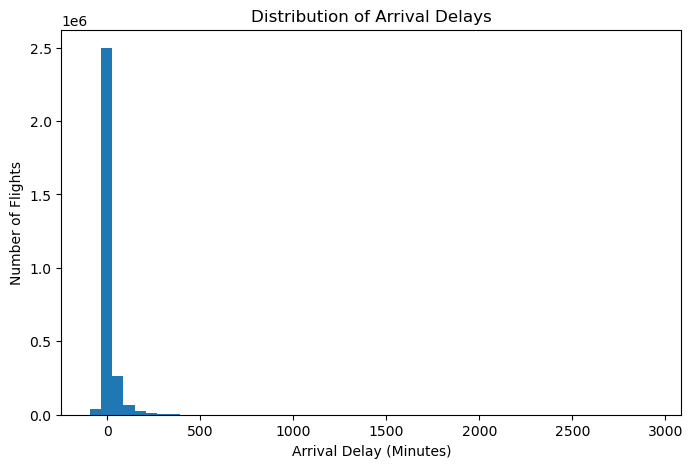

In [24]:
# Distribution of ARR_DELAY visualized with a histogram
flights['ARR_DELAY'].plot(kind='hist', bins=50, figsize=(8,5))
add_labels('Distribution of Arrival Delays', 'Arrival Delay (Minutes)', 'Number of Flights')

This histogram shows that arrival delays are extremely right-skewed, with a majority of the flights clustered near zero minutes of delay. Most flights arrive on time or only slightly late or early, this created the tall spike at the left side of the distribution. Only a very few number of flights experience long or extreme delays. The long tail stretching to the right shows rare, but very large delay events which inflate the overall spread of the data. 

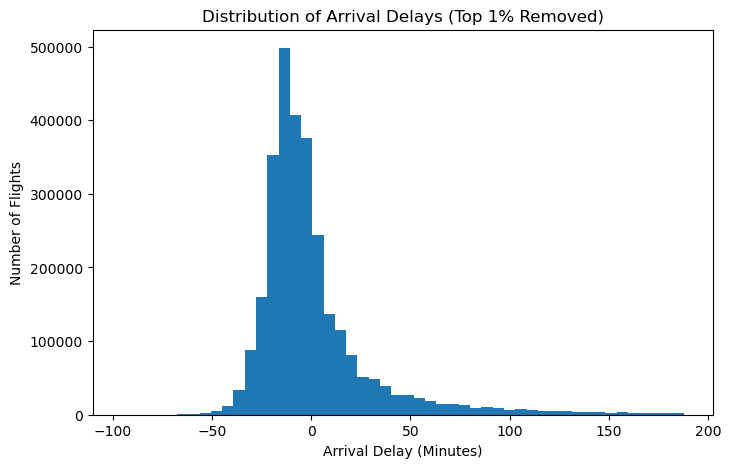

In [25]:
# Remove top 1% in arrival delay histogram
arrival_delays_trimmed = flights[flights['ARR_DELAY'] < flights['ARR_DELAY'].quantile(0.99)]
arrival_delays_trimmed['ARR_DELAY'].plot(kind='hist', bins=50, figsize=(8,5))
add_labels('Distribution of Arrival Delays (Top 1% Removed)', 'Arrival Delay (Minutes)', 'Number of Flights')

Removing the top 1% of extreme delays reveals the true and everyday shape of arrival-delay behavior. The histogram becomes much more interpretable, most flights cluster tightly around zero with a clear peak just below on-time arrival. The right-skew shows that postitive delays happen slightly more than early arrivals. This trimmed view highlights that the typical delays fall within a narrow range. 

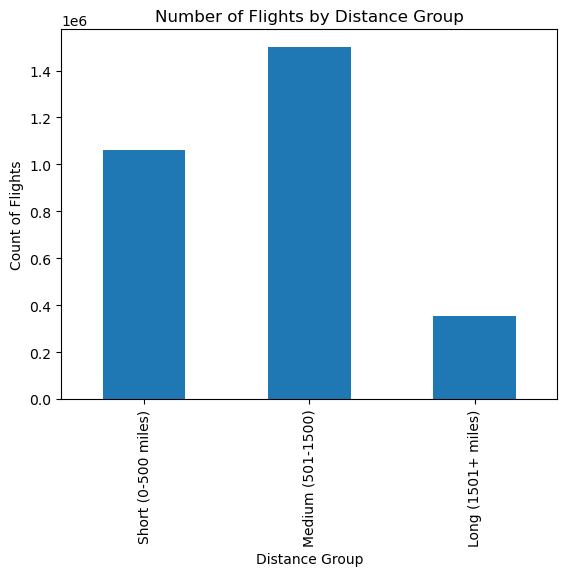

In [26]:
# Bar chart of distance group counts
flights['DISTANCE_GROUP'].value_counts().sort_index().plot(kind='bar')
add_labels('Number of Flights by Distance Group', 'Distance Group', 'Count of Flights')

This bar chart shows the amount of flights that fall into each distance category, short/medium/long. It is clear from the graph that medium distance flights (501-1500) are the most common, around 1.5 million flights at this distance. Short distance flights (0-500) are the second most common with just over 1 million flights. Long distance flights (1501+) are the least common with roughly 350,000 flights. This graph indicates that regional and mid-range routes domincate the air travel. 

### Exploratory Analysis

This section will focus on exploring the relationship between distance and arrival delays. A scatterplot and boxplot visualization will be included. 

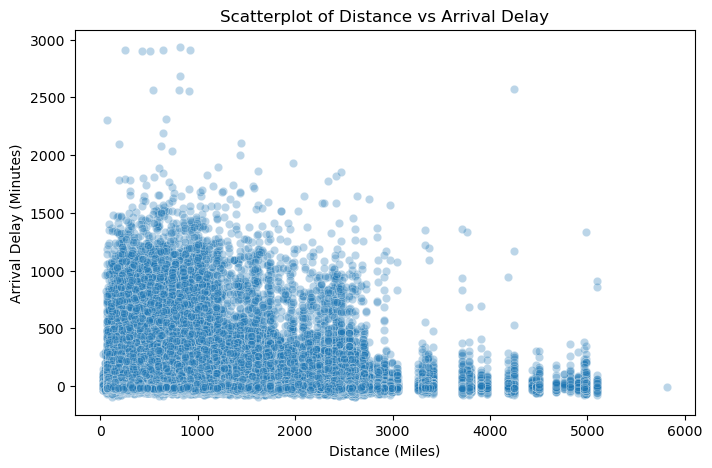

In [27]:
# Scatterplot of relationship between distance and arrival delay
plt.figure(figsize=(8,5))
sns.scatterplot(data=flights, x='DISTANCE', y='ARR_DELAY', alpha=0.3)
add_labels('Scatterplot of Distance vs Arrival Delay', 'Distance (Miles)', 'Arrival Delay (Minutes)')

This scatterplot shows the relationship bwteen flight distance (x-axis) and arrival delay in minutes (y-axis). It appears that there s no clear upwards trend as distance increases, this means that longer flights to not consistently have larger arrival delays. Most delays are small, the majority of points cluster close to 0 minutes in delay. It can also be seen that extreme delays happen mostly on short/medium flights, very large delays such as over 1000 minutes appear mostly under about 3000 miles. 

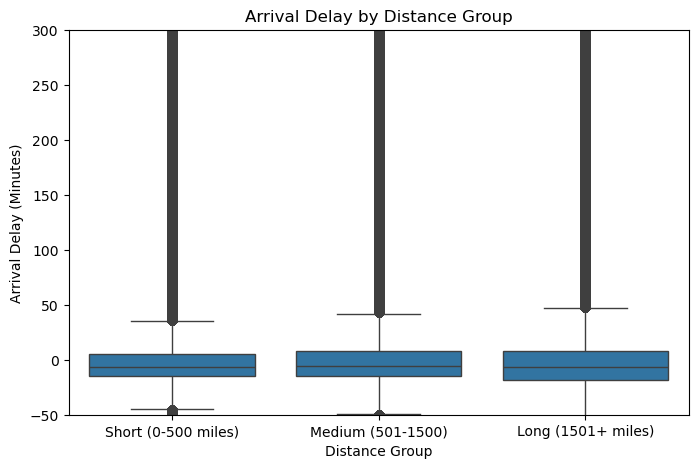

In [28]:
# Boxplot of arrival delay by distance group
plt.figure(figsize=(8,5))
sns.boxplot(data=flights, x='DISTANCE_GROUP', y='ARR_DELAY')
plt.ylim(-50, 300)
add_labels('Arrival Delay by Distance Group', 'Distance Group', 'Arrival Delay (Minutes)')

In the boxplot above, the y-axis was limited to -50 to 300 to exclude extreme outliers as they lessened the readability of the visualization. This adjustment preserves all data while allowing the distribution of arrival delays to be clearly visualized. It looks like both the median and interquartile ranges are very similar for all three categories. They all have medians slightly below 0 which indicates that the typical flight arrives a little early, regardless of distance. The middle 50% of delays is similar across all distances. Long-distance flights appear to have a slightly wider range within this visible visual. 

In [29]:
# Compare mean and median arrival delays by distance group
flights.groupby('DISTANCE_GROUP')['ARR_DELAY'].agg(['mean', 'median', 'std', 'count'])

,mean,median,std,count
DISTANCE_GROUP,,,,
Short (0-500 miles),3.324295,-7.0,48.373124,1060200
Medium (501-1500),5.159527,-6.0,52.292053,1500383
Long (1501+ miles),3.254675,-7.0,54.386754,353219


### Correlation Test

In [30]:
r, p = pearsonr(flights['DISTANCE'], flights['ARR_DELAY'])
print("Correlation coeffecient (r):", r)
print("P-value:", p)

Correlation coeffecient (r): 0.0018838368862803363
P-value: 0.001301335400930382


According to Pearson's correlation test. The coeffecient is extremely close to zero (~0.00188), which means that there is no meaningful linear relationship between flight distance and arrival delay. As distance increases, delay minutes do not increase or decrease. The p-value is below 0.05, so the test is statistically significant. This significance, however, is most likely driven by the very large sample size with over 2 million flights. 

In [ ]:
# Convert notebook to html
!python -m nbconvert --to html analysis.ipynb

[NbConvertApp] Converting notebook analysis.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 675574 bytes to analysis.html
